# Time Series and Machine Learning

Author: Ethan Robert A. Casin

---

## Overview

In this notebook, students will learn:
1. application of Machine Learning methods to time series
2. common baseline methods for time series forecasting
3. pre-processing methods and evaluation for ml time series forecasting
4. basic single-step and multi-step forecasting methods

---

We've already learned fundamental concepts of time series from the previous lecture. The concepts found there would help set everyone up to learn more in-depth time series analysis concepts. Now let's try to merge what we know from your ML 1 and apply it to time series forecasting.

In [25]:
import warnings 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
from typing import Tuple

plt.rcParams["figure.figsize"] = (15, 5)

warnings.filterwarnings('ignore')

# Throwback: ARIMA

To begin our lecture, let's review our ARIMA model using the sunspots data set from `statsmodels`. 

In [26]:
from statsmodels.tsa.arima.model import ARIMA

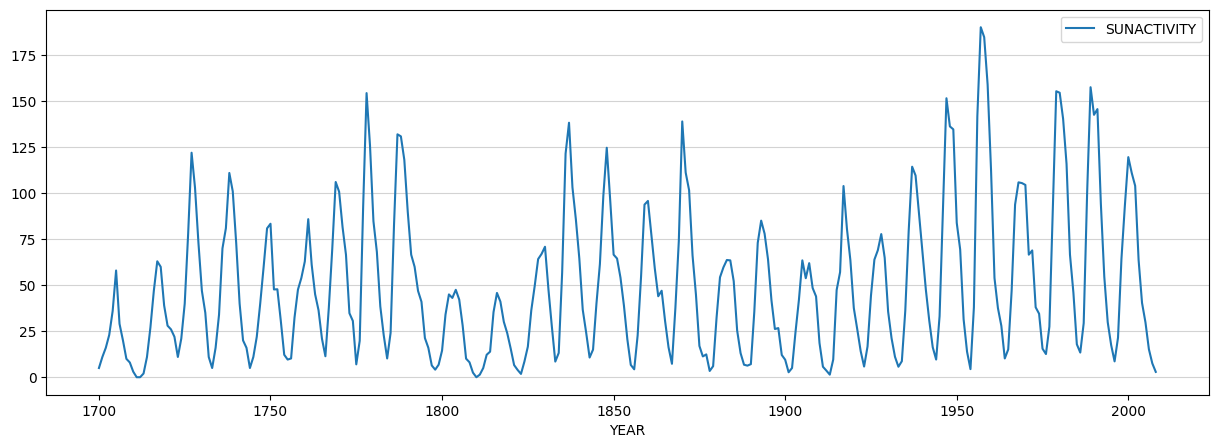

In [27]:
df = sm.datasets.sunspots.load_pandas().data
df["YEAR"] = df["YEAR"].astype(int)
df.set_index("YEAR", inplace=True)

df.plot()
plt.grid(axis="y", c="lightgray")
plt.show()

Let's do a typical split 80-20 split. Since this is sequential data, it's just a matter of taking out the last n points for the test set. Let's stick to basics and not worry about a validation set for the rest of the lecture.

The plot below shows our training and test sets. For the remainder of this lecture, it should be apparent already that relying purely on metrics is not the best way to evaluate time series models. We need to enforce that we should always visualize our results when evaluating time series models as they provide more insight to you.

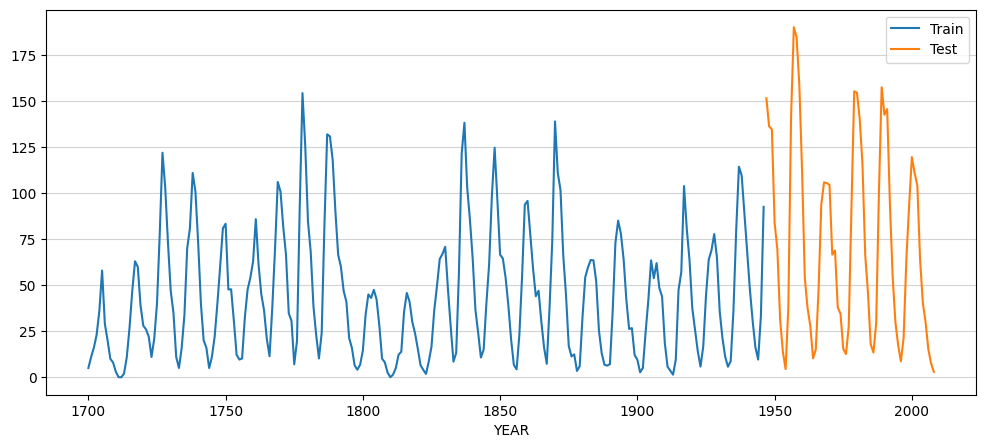

In [28]:
test_prop = 0.2 # we get the last 20% from our data
n_points = df.shape[0]
test_pts = round(n_points * test_prop)

train = df.iloc[:-test_pts]
test = df.iloc[-test_pts:]

## Plot
fig, ax = plt.subplots(figsize=(12,5))

train.plot(ax=ax)
test.plot(ax=ax)

plt.legend(["Train", "Test"])
plt.grid(axis="y", c="lightgray")
plt.show()

We'll simply borrow our defined parameters from before to train our ARIMA model. Once we've trained our model, we'll then try to forecast n steps ahead.

MSE: 1485.90


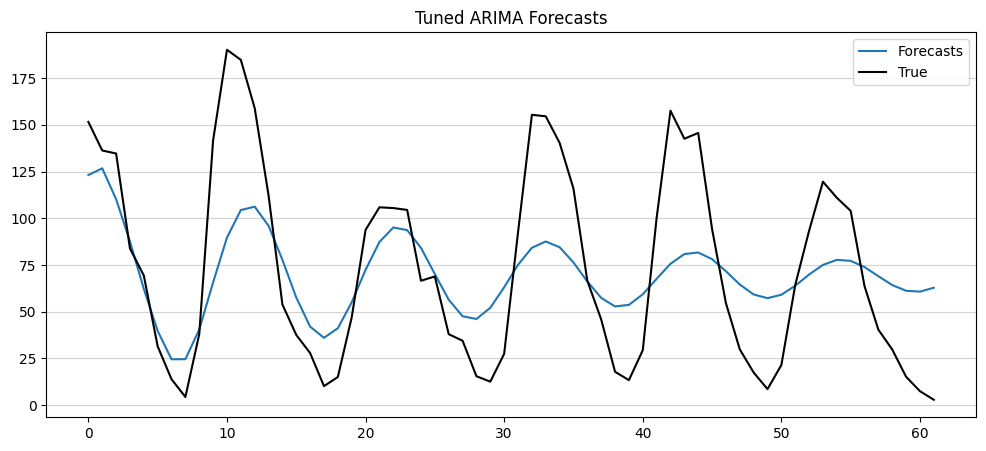

In [29]:
p, d, q = 8, 1, 1
arima = ARIMA(train, order=(p, d, q))
trained_arima = arima.fit()

aimra_forecasts = trained_arima.forecast(steps=test_pts)

print(f"MSE: {mean_squared_error(test.values.flatten(), aimra_forecasts):.2f}")

plt.figure(figsize=(12, 5))
plt.plot(aimra_forecasts.values, label="Forecasts")
plt.plot(test.values.flatten(), c="black", label="True")
plt.title("Tuned ARIMA Forecasts")
plt.legend()
plt.grid(axis="y", c="lightgray")
plt.show()

It should be known by now that ARIMA and similar linear methods tend to suffer if we want to predict `n` steps ahead. Within this lecture, we would need to understand how we could improve on this. Our means would be to use machine learning, but you can apply the same methodologies to ARIMA.

# But first, baselines.

Baselines are important, as they provide us a way to evaluate our models during development. There are three basic baseline methods in time series, namely, `mean method`, `naive`, and `seaonal naive`. Each method is relatively simple to implement and they all follow straightforward concepts.

Whenever you assess your model, always plot out your forecasts

## Mean Method

As the name suggests, our forecasts for future values are equal to the mean of our historical data. If we let the historical data be denoted as $y_1, \dots, y_T$, then we can write the forecasts as

\begin{align*}
\hat{y}_{T + h | T} = \bar{y} = \frac{1}{T}\sum_{i=1}^Ty_i
\end{align*}

The notation $\hat{y}_{T + h | T}$ is just a short-hand way of saying "the forcast for $y_{T + h}$ based on the historical data $y_1, \dots, y_T$".

In [30]:
# We just get our training set's mean
# then project it to the number of test points we need
mean = train.mean()
mean_forecasts = pd.DataFrame([mean] * test_pts)

mean_forecasts["YEAR"] = test.index # hack-y way of doing it
mean_forecasts.set_index("YEAR", inplace=True)
mean_forecasts

,SUNACTIVITY
YEAR,
1947,43.726721
1948,43.726721
1949,43.726721
1950,43.726721
1951,43.726721
...,...
2004,43.726721
2005,43.726721
2006,43.726721


Let's plot our results!

MSE: 3688.30


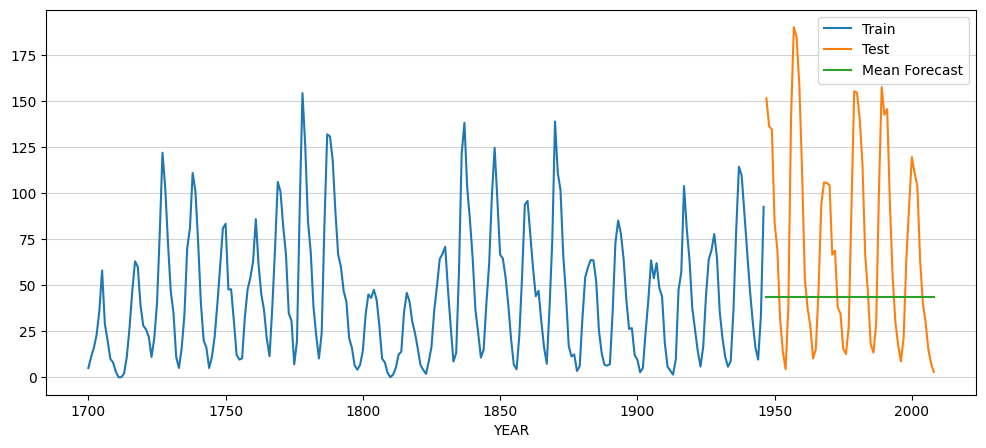

In [31]:
fig, ax = plt.subplots(figsize=(12,5))

print(f"MSE: {mean_squared_error(test.values, mean_forecasts.values):.2f}")

train.plot(ax=ax)
test.plot(ax=ax)
mean_forecasts.plot(ax=ax)

plt.legend(["Train", "Test", "Mean Forecast"])
plt.grid(axis="y", c="lightgray")
plt.show()

Unsurprisingly, we didn't get any good results. Because we've just used a single value -- the mean -- for all the `n` steps we needed to forecast, it shouldn't be shocking that we have a flat line. After all, if your model performs worse than taking the mean, then you're probably better of using the average of your historical than spend time creating a model.

## Naive

We can think of the naive forecasts as a little (sometimes literal) step up from the mean method. For the naive method, we simply set all forecasts to be equal to the last observed value in our historical. That is

\begin{align*}
\hat{y}_{T + h | T} = y_T.
\end{align*}

This definition tells us that all `h` ahead forecasts are equal to the last observed value in our historical denoted as $y_T$.

In [32]:
# We take the last observation from our historical
# then project it to the number of steps we need
naive_forecasts = pd.DataFrame([train.iloc[-1]] * test_pts)

naive_forecasts["YEAR"] = test.index # hack-y way of doing it
naive_forecasts.set_index("YEAR", inplace=True)
naive_forecasts

,SUNACTIVITY
YEAR,
1947,92.6
1948,92.6
1949,92.6
1950,92.6
1951,92.6
...,...
2004,92.6
2005,92.6
2006,92.6


MSE: 3141.60


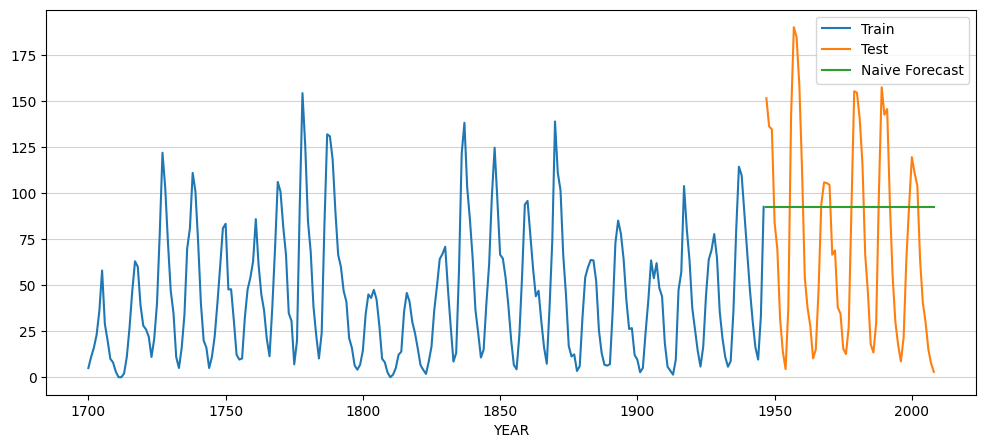

In [33]:
fig, ax = plt.subplots(figsize=(12,5))

print(f"MSE: {mean_squared_error(test.values, naive_forecasts.values):.2f}")

train.plot(ax=ax)
test.plot(ax=ax)
naive_forecasts.plot(ax=ax)

plt.legend(["Train", "Test", "Naive Forecast"])
plt.grid(axis="y", c="lightgray")
plt.show()

We see that the naive forecast is also just a straight line. Looking at the MSE, we do see some improvement over the mean method. 

---

**Question**: What's a smart guess to why the naive forecast performs better than taking the mean?

---

## Seasonal Naive

for a seasonal naive, you just get a certain part of the dataset and proejcting that forward. We need to tune the seasonality $m$ or how many periods in the past to actually look.

A more sophisticated naive method leverages the seasonality of our data. Seasonal naive is very useful for data that is highly seasonal. In this method, we set each forecast to be equal to the last observed value from the same season. 

Some examples are:
1. the same month/quarter of the previous year
2. the week / 7 days of the previous month

Formally, we define seasonal naive as

\begin{align*}
\hat{y}_{T + h | T} = y_{T + h - m(k + 1)}
\end{align*}

where $m$ is the seasonal period $k$ is the integer part of $(h - 1) / m$. This actually looks more complicated that it actually is, so let's see how to implement this in practice. For seasonal naive, we need to determine the seasonal period $m$. 

With that, we need to use the ACF plot

---

**Question**: Why the ACF plot to determine the seasonality?

---

you want to use ACF to cascade. If you only get the PACF, you would only get that they correlated sila, but you don't see how it changes OVER time.

for seasonal periods, the goal to understand the ACF is to see when does the pattern occur. NOT the same rule of thumb with the previous rule of thumb.

In [34]:
from statsmodels.graphics.tsaplots import plot_acf

In [35]:
# Let's define our seasonal naive function already
# Try to study this and see you understand the code

def snaive(data: pd.Series, m: int = 3, horizon: int = test_pts):
    last_pts = data.iloc[-m:].values.ravel()

    # Repeat the last observations (horizon / m) times
    forecasts = np.tile(last_pts, horizon)[:horizon] # remove the extra pts
    return pd.Series(forecasts)

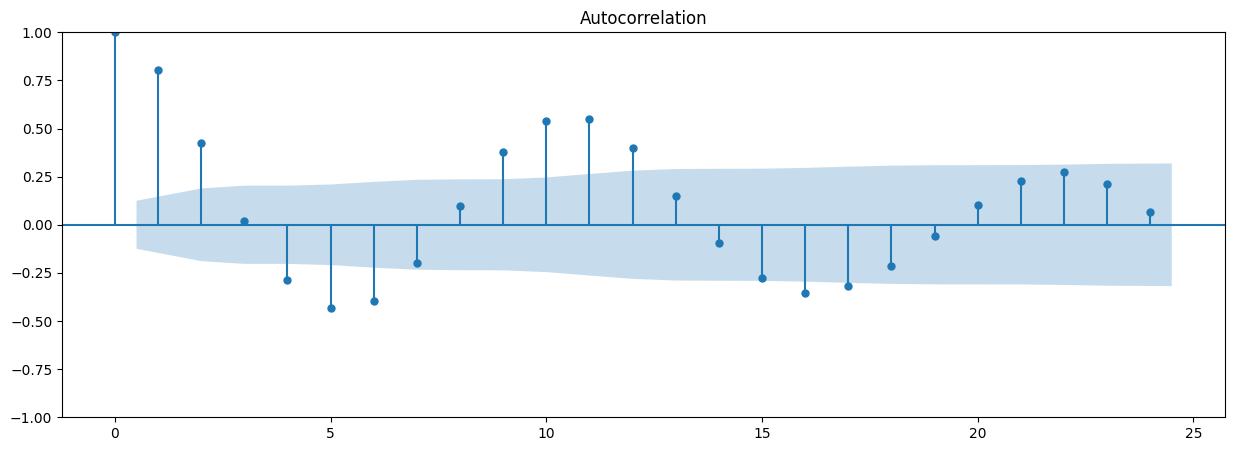

In [36]:
plot_acf(train)
plt.show()

Eyeballing it, we find that there seems to be a recurring pattern every 10 lags or so. Let's use that for now.

11 is better because of the cycle of 11 years for the sunspot data

In [37]:
snaive_forecasts = pd.DataFrame(snaive(train, 10))
snaive_forecasts["YEAR"] = test.index # hack-y way of doing it
snaive_forecasts.set_index("YEAR", inplace=True)

MSE: 2926.86


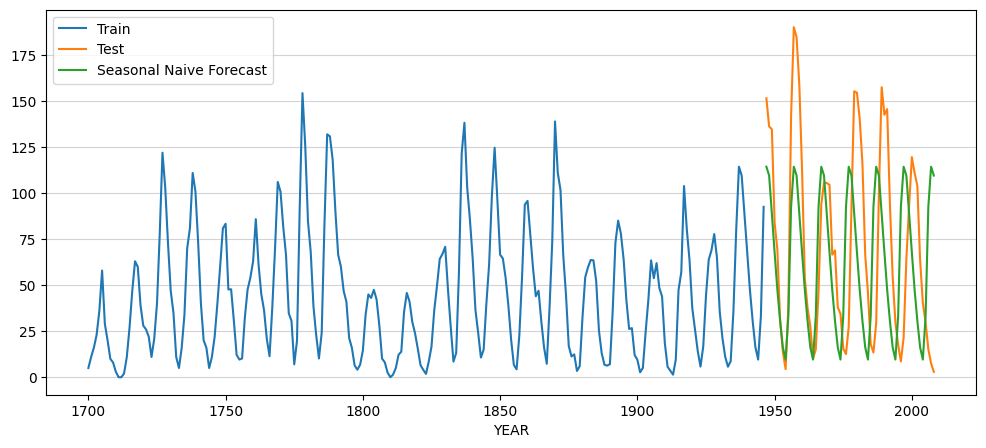

In [38]:
fig, ax = plt.subplots(figsize=(12,5))

print(f"MSE: {mean_squared_error(test.values, snaive_forecasts.values):.2f}")

train.plot(ax=ax)
test.plot(ax=ax)
snaive_forecasts.plot(ax=ax)

plt.legend(["Train", "Test", "Seasonal Naive Forecast"])
plt.grid(axis="y", c="lightgray")
plt.show()

We can definitely see some improvements from our baseline. At this point it's okay to start sweating and doubt if we could beat this. 

*Fun fact: sunspot activity actually has a cycle of around 11 years. Not too bad for us because we only relied on the ACF plot.*

# Creating our Train and Test Splits

Before we do any actual ML modeling, let's make sure first we can make our algorithms understand and accept our time series. Given our univariate time series, we only have 1 column. For machine learning, this is basically unhelpful. So we need to do something with our time series for our algorithms make sense of things.

## Preprocessing

---

**Quesion**: What's the current issue with our train and test splits right now?

*Hint: how would you run your model on the test set?*

---

In [39]:
print("-" * 20)
print("Train")
print("-" * 20)
display(train)

print("-" * 20)
print("Test")
print("-" * 20)
display(test)

--------------------
Train
--------------------


,SUNACTIVITY
YEAR,
1700,5.0
1701,11.0
1702,16.0
1703,23.0
1704,36.0
...,...
1942,30.6
1943,16.3
1944,9.6


--------------------
Test
--------------------


,SUNACTIVITY
YEAR,
1947,151.6
1948,136.3
1949,134.7
1950,83.9
1951,69.4
...,...
2004,40.4
2005,29.8
2006,15.2


## Setting it up for the future

In most, if not all, practical applications of machine learning on time series, we need to let our model be trained on historical data. We then have it do a forecast the first test point based on the last `n` observations of our historical. We therefore need a `lookback` window, or that `n` observations from the training set for us to do a forecast on our test set.

Hence, we need to include some points from our training set into our test set. In a less accurate way, you can think of this as a reverse data leak situation -- we instead inject information of the training set into the test set. The goal of doing this is so that our machine learning model would use the last `lookback` points as the `X` values in order to predict the first test `y` values.

In [40]:
def train_test_split(data: pd.Series, lookback: int = 12, test_size: int = 12) -> Tuple[pd.Series, pd.Series]:
    """Create a train-test split on your pd.Series data.

    Parameters:
    -----------
    data (pd.Series): The univariate time series provided
    lookback (int): The lookback periods to consider
    test_size (int): The length of the test set

    Returns:
    --------
    Tuple (pd.Series): The (train, test) pandas series generated
    """
    
    split = data.shape[0] - test_size
    return (
        data.iloc[:split],
        data.iloc[split - lookback: ]
    )

Training instances: (247,)
Test instances: (72,)
N actual test points: 62


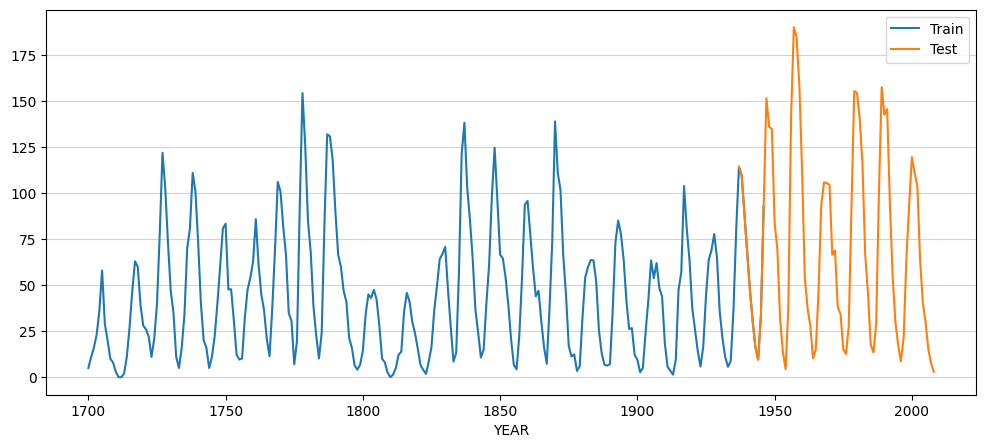

In [41]:
lookback = 10 # lookback in years
# lookback is usually the same as the seasonal period fro the sake of consistency
test_size = test_pts # let's just copy our original test_pts
horizon = 1 # forecasting 1 year ahead

new_train, new_test = train_test_split(df["SUNACTIVITY"], lookback=lookback, test_size=test_size)

print(f"Training instances: {new_train.shape}")
print(f"Test instances: {new_test.shape}")
print(f"N actual test points: {test_size}")
## Plot

fig, ax = plt.subplots(figsize=(12,5))

new_train.plot(ax=ax)
new_test.plot(ax=ax)

plt.legend(["Train", "Test"])
plt.grid(axis="y", c="lightgray")
plt.show()

Since we have `lookback = 10`, we find that our test instances is 72. However, we only really need to do forecasts on 62 points. To make it more concrete, let's now create our `X` and `y` arrays for our machine learning model.

In [42]:
def create_xy(series: pd.Series, lookback: int = 12, horizon: int = 1) -> Tuple[np.ndarray, np.ndarray]:
    """Create the X and y arrays from a pd.Series object. The `lookback`
    determines the number of features we would include in X. While the
    `horizon` paramter informs us how many points we'll need to forecast.

    Paramters:
    ----------
    series (pd.Series): the (n, 1) time series to be sliced into X and Y
    lookback (int): the lookback window to consider (default=12)
    horizon (int): the number of points to forecast for each row in X (default=1)

    Returns:
    -------
    (X, y) (Tuple): a tuple of ndarrays
    """
    x = []
    y = []
    
    series_size = series.shape[0]
    for i in range(series_size):
        
        # break loop if series is less than the required time horizon
        if series.iloc[(i + lookback): (i + lookback + horizon)].shape[0] < horizon:
            break
        x.append(
            series.iloc[i: (i + lookback)]
        )
        y.append(
            series.iloc[(i + lookback): (i + lookback + horizon)]
        )
    x = np.dstack(x)
    y = np.dstack(y)

    # Reshape x to (samples, features, lookback)
    x = np.swapaxes(x, 0, 2)
    # Then flatten (samples, features * lookback)
    x = x.reshape(x.shape[0], x.shape[1] * x.shape[2])

    # Reshape y tp (samples, horizon)
    y = np.swapaxes(y, 0, 2)
    y = y[:, :, 0]


    
    return x, y

In [43]:
train_X, train_y = create_xy(new_train, lookback=lookback, horizon=horizon)
test_X, test_y = create_xy(new_test, lookback=lookback, horizon=horizon)

print("X-Y Shapes")
print("=" * 20)
print(f"Train X: {train_X.shape}")
print(f"Train Y: {train_y.shape}")
print(f"Test X: {test_X.shape}")
print(f"Test Y: {test_y.shape}")

X-Y Shapes
Train X: (237, 10)
Train Y: (237, 1)
Test X: (62, 10)
Test Y: (62, 1)


Wait what happened?

---

**Question:** Can you explain why `Test X` now has 62 rows?

---

To see what our `X` and `y` values look like, we can think of `X` as the actual time series but was formatted to have `lookback` features. If you notice `Train X` and `Train Y` whatever the value of `y` gets appended to the succeeding row of `X`. Therefore, when we try to predict on the test set, we actually just used the last 10 points from the training set to predict the first value of the test set. 

In [44]:
print("-" * 20)
print("Train X")
print("-" * 20)
display(train_X[:2])

print("-" * 20)
print("Train Y")
print("-" * 20)
display(train_y[:2])

--------------------
Train X
--------------------


array([[ 5., 11., 16., 23., 36., 58., 29., 20., 10.,  8.],
       [11., 16., 23., 36., 58., 29., 20., 10.,  8.,  3.]])

--------------------
Train Y
--------------------


array([[3.],
       [0.]])

Now that's cool and all, but you're probably wondering about a lot of things right now. An important thought you should have right now is that we're essentially converting this into a regression problem.

--- 
**Question**: why is it important to process our time series into a supervised regression problem?<br>
**Question**: what other patterns did you spot on `Train X`? (you can expand the display to include more rows)

---

# Time Series as a Regression Problem

It's important to revisit the concept of autoregression right now. Autoregression is the idea of using *lagged* values of a random variable as predictors for future observations. 

Revisiting this, we define autoregression as

$$y_t = c + \phi_1y_{t-1} + \dots + \phi_py_{t-p} + \epsilon_t$$

More generally, this data generating process can be written as

$$y_t = f(y_{t-1}, y_{t-2}, \dots, y_{t-p}),$$

where $f$ is some function. We can therefore think of using machine learning to estimate $f$ -- the data generating process.


# One-step forecasts

Let's ease into this. For the purposes of this notebook we can use our very basic regression model, `LinearRegression` and our more advanced one `RandomForestRegressor`. 

As the name suggests, one-step forecasts only predict one time step into the future and relying on the actual value of that time step to predict succeeding steps. In some references, one-step forecasts are sometimes called point forecasts.

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [46]:
# Helper function to display performance of the two models
def display_ml_perf(results: dict, metric="MSE") -> None:
    res = pd.DataFrame([results]).T
    res.columns = ["MSE"]
    display(res)

## Uncomplicated: Do a typical ML Flow (Static Training)

Don't quote me on this, but we can do a typical machine learning training and testing, a type I coined static training. The core idea is what you already know: train the machine learning model on the training set and predict on future data. 

This is a relatively simple implementation and let's see how it works

In [47]:
lr_basic = LinearRegression()
rf_basic = RandomForestRegressor(random_state=2212)

In [48]:
lr_basic.fit(train_X, train_y)
rf_basic.fit(train_X, train_y)

lr_forecasts = lr_basic.predict(test_X)
rf_forecasts = rf_basic.predict(test_X)

from the code here, we are feeding back the actual values in the test. The main concern here is that you are dependent on the actual value.

---

**Question**: What are we doing here?

---

In [49]:
# Review: what are we doing?

print("Train X")
print("-" * 20)
display(train_X[-1, :])

print("Test X")
print("-" * 20)
display(test_X[:2, :])

Train X
--------------------


array([ 79.7, 114.4, 109.6,  88.8,  67.8,  47.5,  30.6,  16.3,   9.6,
        33.2])

Test X
--------------------


array([[114.4, 109.6,  88.8,  67.8,  47.5,  30.6,  16.3,   9.6,  33.2,
         92.6],
       [109.6,  88.8,  67.8,  47.5,  30.6,  16.3,   9.6,  33.2,  92.6,
        151.6]])

,MSE
Linear Regression,381.422045
Random Forest,654.134215


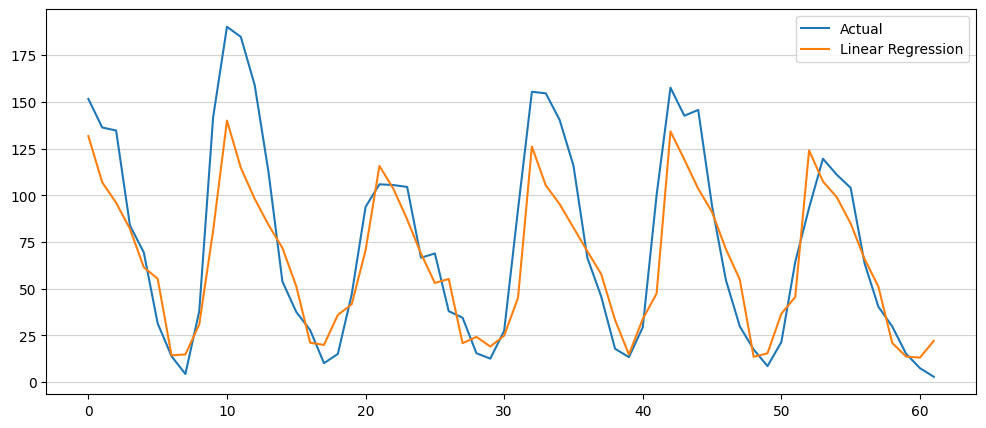

In [52]:
basic_results = {
    "Linear Regression": mean_squared_error(test_y, lr_forecasts),
    "Random Forest": mean_squared_error(test_y, rf_forecasts)
}

display_ml_perf(basic_results)

# Plot results

fig, ax = plt.subplots(figsize=(12,5))

x_range = range(test_y.shape[0])

plt.plot(x_range, test_y)
#plt.plot(x_range, lr_forecasts)
plt.plot(x_range, rf_forecasts)

plt.legend(["Actual", "Linear Regression", "Random Forest"])
plt.grid(axis="y", c="lightgray")
plt.show()

random forest is pretty conservative, it seems to be predicting the same thing

We see that our machine learning models generally perform better than our baselines! We also notice that both models are able to predict the test set more accurately than seasonal naive.

Whew.

Let's do some additional validation. Look, the plot and metrics above were helpful and all but maybe we can do an additional layer of analysis to see how good each model is. We can turn to our old reliable for regression: R2 score.

R2 is helpful for the modellers but not helpful for the audience, so use the actual v predicted

---

**Question:** In the context of time series, how does the R2 score help us evaluate our model? 

---

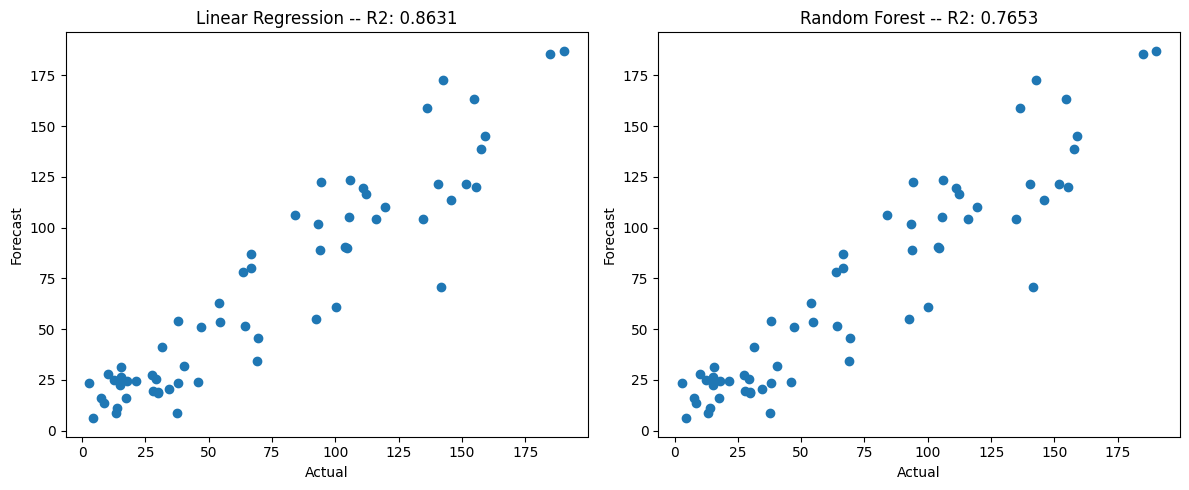

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(test_y, lr_forecasts)
ax[1].scatter(test_y, lr_forecasts)

ax[0].set_title(f"Linear Regression -- R2: {r2_score(test_y, lr_forecasts):.4f}")
ax[1].set_title(f"Random Forest -- R2: {r2_score(test_y, rf_forecasts):.4f}")

ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Forecast")

ax[1].set_xlabel("Actual")
ax[1].set_ylabel("Forecast")

plt.tight_layout()

Visually both models seem to perform quite similarly. However, looking at the R2 score we find that Linear Regression is able to for our test set better than Random Forest. 

On a more traditional sense, are we able to know right now if any of our models overfitted?

One way to check this is by looking at the fitted values. To get these, we simply try to make predictions on the training set and evaluate them. For simplicity, let's use the R2 score.

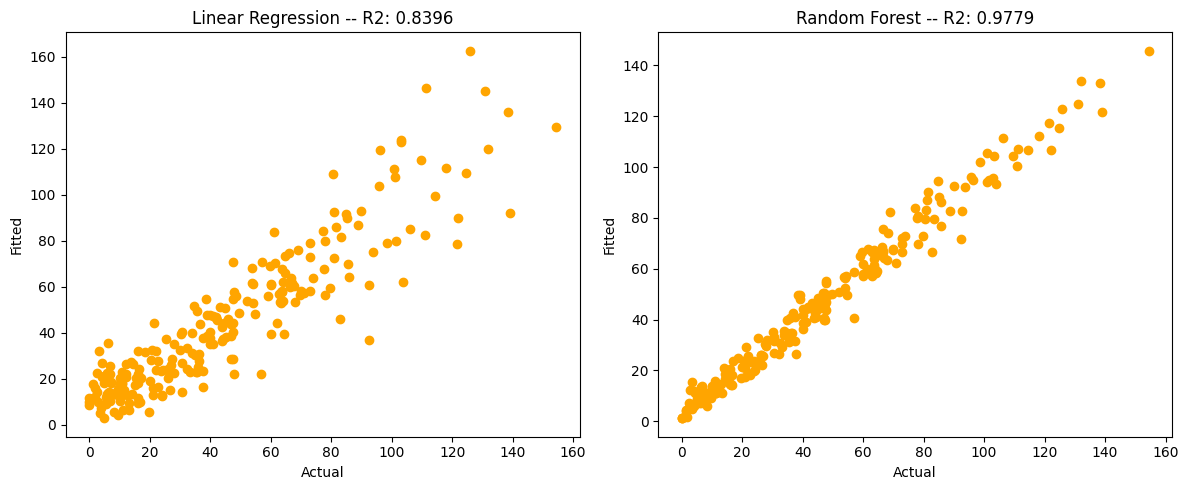

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

lr_train_f = lr_basic.predict(train_X)
rf_train_f = rf_basic.predict(train_X)

ax[0].scatter(train_y, lr_train_f, color="orange")
ax[1].scatter(train_y, rf_train_f, color="orange")

ax[0].set_title(f"Linear Regression -- R2: {r2_score(train_y, lr_train_f):.4f}")
ax[1].set_title(f"Random Forest -- R2: {r2_score(train_y, rf_train_f):.4f}")

ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Fitted")

ax[1].set_xlabel("Actual")
ax[1].set_ylabel("Fitted")

plt.tight_layout()

At least looking from the R2 scores, we find that our Random Forest Model is overfitting.

**Note: Using any of the aforementioned metrics in isolation could be considered bad practice to evaluate your model. For example, relying solely on R2 score has its drawbacks and we would need to supplement it with other evaluation metrics. Feel free to read this informative forum [post](https://stats.stackexchange.com/questions/101546/what-is-the-problem-with-using-r-squared-in-time-series-models).**

## Expanded Window vs. Rolling Forecasts

What we learned earlier is to treat time series forecasting as an actual regression problem for time series.

---

**Question**: What's the issue if we do this? What are the assumptions of a regression problem vs a time series problem?

---

We have two types of "moving" forecasts: the expanded window and the rolling (window) forecasts.

## Expanded Window

for every prediction, you keep on training and training on even the new data (predicted) points

There is a computational cost with retraining every window.

We are assuming here that the past values are actually important to new data points (there is a problem on relevancy)

Now a big drawback of doing a typical regression problem for machine learning is that we're assuming the data is generally static. In time series, however, it's "moving". Therefore we can improve on our previous method by retraining our model for new observations before doing a forecast.

We'll deal with a simple case for now. We'll train our model on our entire historical data and then for every actual value from the "test" set or future value, we retrain our model.

In [54]:
lr_expanded = LinearRegression()
rf_expanded = RandomForestRegressor(random_state=2212)

In [55]:
%%time

T = len(test_y)
whole_historical = new_train.reset_index(drop=True).copy()
lookback = 10

lr_ex_forecasts = []
rf_ex_forecasts = []

for t in range(T):
    X, y = create_xy(whole_historical, lookback=lookback, horizon=1)
    lr_expanded.fit(X, y)
    rf_expanded.fit(X, y)

    # Forecast the next step (outside of training)
    # We do this by getting the last row of our training
    x_next = whole_historical.iloc[-lookback:].values.reshape(1, -1)

    lr_ex_forecast = lr_expanded.predict(x_next)
    rf_ex_forecast = rf_expanded.predict(x_next)

    lr_ex_forecasts.append(lr_ex_forecast)
    rf_ex_forecasts.append(rf_ex_forecast)
    
    # We then save the actual y_test value to our historical
    # Since we're simulating a retrain on actual values 
    # every time a new observation comes in
    whole_historical = pd.Series(np.append(whole_historical, test_y.flatten()[t]))    


CPU times: user 7.01 s, sys: 199 ms, total: 7.2 s
Wall time: 7.31 s


,MSE
Linear Regression,378.024403
Random Forest,378.024403


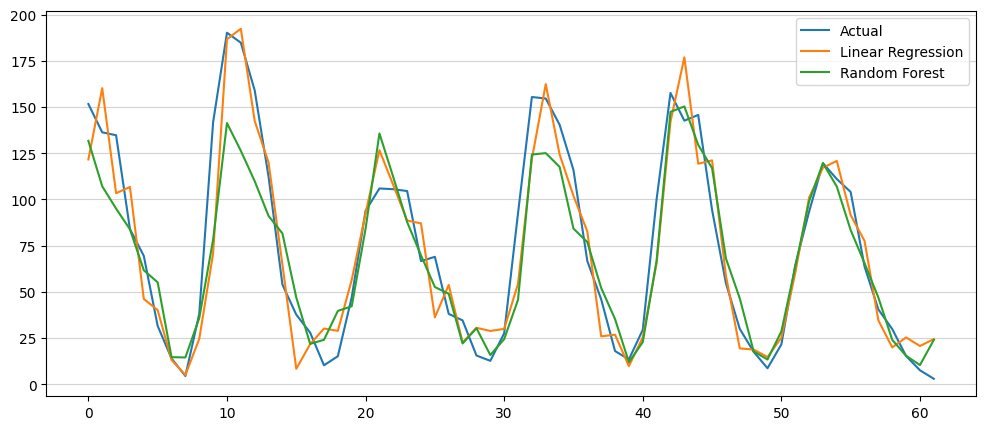

In [56]:
# convert forecasts into an array and flatten
lr_forecasts = np.asarray(lr_ex_forecasts).flatten()
rf_forecasts = np.asarray(rf_ex_forecasts).flatten()

test_y_flat = test_y.copy().flatten()

exp_results = {
    "Linear Regression": mean_squared_error(test_y_flat, lr_forecasts),
    "Random Forest": mean_squared_error(test_y_flat, lr_forecasts)
}

display_ml_perf(exp_results)

# Plot results
fig, ax = plt.subplots(figsize=(12, 5))

x_range = range(test_y.shape[0])

plt.plot(x_range, test_y_flat)
plt.plot(x_range, lr_forecasts)
plt.plot(x_range, rf_forecasts)

plt.legend(["Actual", "Linear Regression", "Random Forest"])
plt.grid(axis="y", c="lightgray")
plt.show()

---

**Question**: Did our models improve?<br>
**Question**: What's the main drawback of the expanded window approach?

---

### Walk-Forward Validation

We've glossed over an important concept in evaluating time series for "moving" type forecasts. A **walk-forward validation** works as follows

1. The first N% of the dataset will be used to train the model
2. The remaining (100 - N)% of the dataset will be the evaluation / test set
3. For each step in the test set, the model will be retrained or a model will be trained.

A one-step ahead forecast will be stored for later evaluation, while the actual value from the test set will be added to the training dataset for the next iteration. 

This is what we did on the expanded window approach we have.


---

**Question**: What's the main difference between the traditional ML approach and the expanded window approach?<br>
**Question**: What' a big drawback of an expanded window approach?

---

## Rolling Forecast

rolling window has a limit on the observation. One pro is that the computation is less than expanded window.
Second, more recent points have more relevance.

There's a tuning for this one since you have to deal with the the lookback window and the forecasting window. We could try to define the optimal parameters or just stick to heuristics

A rolling window forecast improves on the expanded window by allowing only a fixed window size for training. We'll acutally just modify our slicing and we have our rolling forecast already.

a black swan event is an unpredictable event
a dragon king event is more predictable  (there have been multiple pandemics in the past). COVID was more predictable where they happen so its not unpredictable

if data recorded in minutes, its besst to use rolling.

In [57]:
lr_rolling = LinearRegression()
rf_rolling = RandomForestRegressor(random_state=2212)

In [58]:
%%time

T = len(test_y)
whole_historical = new_train.reset_index(drop=True).copy()
lookback = 10
training_window_size = 10 * 3 # 30 years worth for (re)training

lr_roll_forecasts = []
rf_roll_forecasts = []

for t in range(T):
    X, y = create_xy(whole_historical, lookback=lookback, horizon=1)
    
    if X.shape[0] > training_window_size:
        X = X[-training_window_size:]
        y = y[-training_window_size:]

    lr_rolling.fit(X, y)
    rf_rolling.fit(X, y)

    # Forecast the next step (outside of training)
    # We do this by getting the last row of our training
    x_next = whole_historical.iloc[-lookback:].values.reshape(1, -1)

    lr_roll_forecast = lr_rolling.predict(x_next)
    rf_roll_forecast = rf_rolling.predict(x_next)

    lr_roll_forecasts.append(lr_roll_forecast)
    rf_roll_forecasts.append(rf_roll_forecast)
    
    # We then save the actual y_test value to our historical
    # Since we're simulating a retrain on actual values 
    # every time a new observation comes in
    whole_historical = pd.Series(np.append(whole_historical, test_y.flatten()[t]))    


CPU times: user 2.93 s, sys: 104 ms, total: 3.04 s
Wall time: 3.17 s


,MSE
Linear Regression,740.379285
Random Forest,740.379285


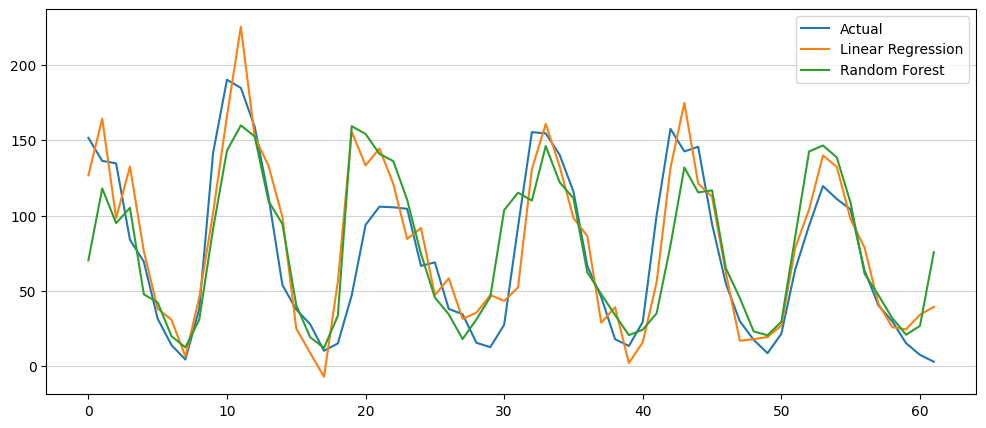

In [59]:
# convert forecasts into an array and flatten
lr_forecasts = np.asarray(lr_roll_forecasts).flatten()
rf_forecasts = np.asarray(rf_roll_forecasts).flatten()

test_y_flat = test_y.copy().flatten()

roll_results = {
    "Linear Regression": mean_squared_error(test_y_flat, lr_forecasts),
    "Random Forest": mean_squared_error(test_y_flat, lr_forecasts)
}

display_ml_perf(roll_results)


# Plot
fig, ax = plt.subplots(figsize=(12, 5))

x_range = range(test_y.shape[0])

plt.plot(x_range, test_y_flat)
plt.plot(x_range, lr_forecasts)
plt.plot(x_range, rf_forecasts)

plt.legend(["Actual", "Linear Regression", "Random Forest"])
plt.grid(axis="y", c="lightgray")
plt.show()

It's definitely worse than our expanded window approach. However, it's faster. That's one of the considerations between choosing the two: speed vs accuracy. In practice, however, it is much more common to see a rolling window approach because more recent observations are more important or predictive to future values.

For a small enough data regime, expanded window approaches could be more favorable.

## Time Series Cross Validation

Now how do we tune our models in time series?

If you noticed we introduced all kinds of paramters that you can tune. It could be your `lookback`, `horizon`, `step_size`, etc. Is there a way to tune them all? This section will introduce time series cross validation. An important way of tuning our models during development. The idea is simple and if you understood how expanded window forecasting works, then the concept isn't fundamentally different.

<figure>
    <img src="figures/time-series-cv-1.png" width="800px"></img>
    <figcaption>Image retrieved from <a href="https://otexts.com/fpp3/tscv.html">here.</a></figcaption>
</figure>

The core idea is similar to the expanded window approach, but done on the training set. Below is a simple example of doing a time series cross validation. We can use the `TimeSeriesSplit` class from `sklearn` to help us come up with our splits.

In [60]:
from sklearn.model_selection import TimeSeriesSplit

In [61]:
lr_expanded_2 = LinearRegression()
rf_expanded_2 = RandomForestRegressor(random_state=2212)

In [62]:
# Create x-y split before doing the cross validation split 
X_train_all, y_train_all = create_xy(
    new_train.reset_index(drop=True), lookback=10, horizon=1
)
y_train_all = np.asarray(y_train_all).ravel()

tscv = TimeSeriesSplit(n_splits=5)
lr_mse = []
rf_mse = []

for train_idx, val_idx in tscv.split(X_train_all):
    X_train_tmp = X_train_all[train_idx]
    y_train_tmp = y_train_all[train_idx]

    X_val_tmp = X_train_all[val_idx]
    y_val_tmp = y_train_all[val_idx]

    lr_expanded_2.fit(X_train_tmp, y_train_tmp)
    rf_expanded_2.fit(X_train_tmp, y_train_tmp)

    lr_forecasts = lr_expanded_2.predict(X_val_tmp)
    rf_forecasts = rf_expanded_2.predict(X_val_tmp)

    lr_mse.append(mean_squared_error(y_val_tmp, lr_forecasts))
    rf_mse.append(mean_squared_error(y_val_tmp, rf_forecasts))
print(f"Linear Regression TSCV Avg. MSE: {np.mean(lr_mse):.2f} ± {np.std(lr_mse):.2f}")
print(f"Random Forest TSCV Avg. MSE: {np.mean(rf_mse):.2f} ± {np.std(rf_mse):.2f}")

Linear Regression TSCV Avg. MSE: 257.96 ± 69.26
Random Forest TSCV Avg. MSE: 312.54 ± 184.82


We find that for 5 CV splits, Linear Regression is able to understand the data more than our Random Forest. 

#### Tuning `h`

As mentioned, we can use time series cross validation to tune our parameters other than the ones in our model. In this example, let's try to tune how far ahead we can predict. Basically, let's tune `h`.

Basically, we just want to see how good there is $h$ and if the model can capture long term patterns. h=2 and 3 are bad, so not good in forecasting short term, but h=4 and 5 are good

In [63]:
# Create x-y split before doing the cross validation split

horizons = np.arange(1, 6)

horizon_mse = {}
for h in horizons:
    X_train_all, y_train_all = create_xy(
        new_train.reset_index(drop=True), lookback=10, horizon=h
    )
    y_train_all = np.asarray(y_train_all).ravel()
    
    tscv = TimeSeriesSplit(n_splits=5)
    lr_mse = []
    rf_mses = []
    
    for train_idx, val_idx in tscv.split(X_train_all):
        X_train_tmp = X_train_all[train_idx]
        y_train_tmp = y_train_all[train_idx]
    
        X_val_tmp = X_train_all[val_idx]
        y_val_tmp = y_train_all[val_idx]
    
        lr_expanded_2.fit(X_train_tmp, y_train_tmp)    
        lr_forecasts = lr_expanded_2.predict(X_val_tmp)
        lr_mse.append(mean_squared_error(y_val_tmp, lr_forecasts))
    horizon_mse[h] = lr_mse


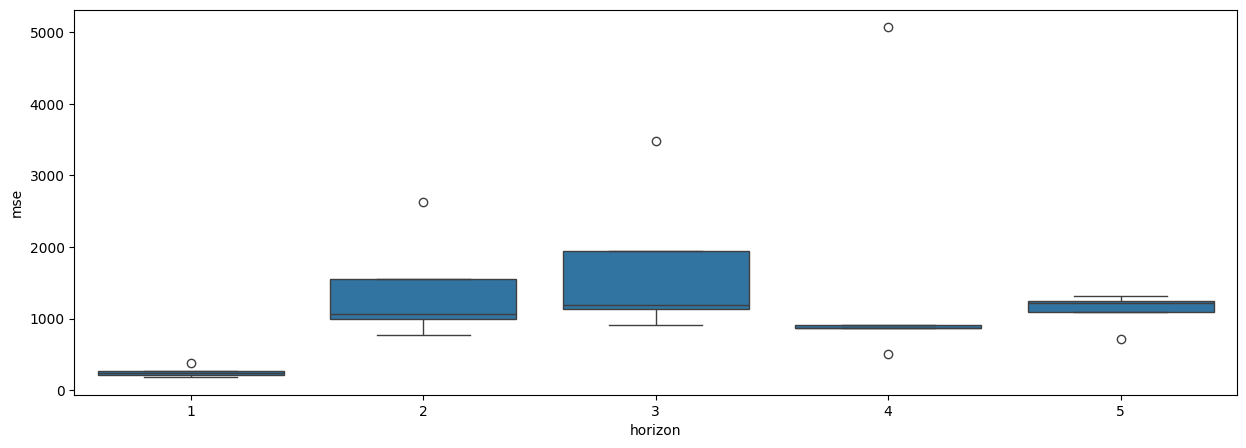

In [64]:
melted = pd.DataFrame(horizon_mse).melt(var_name="horizon", value_name="mse")
sns.boxplot(data=melted, x="horizon", y="mse")
plt.show()

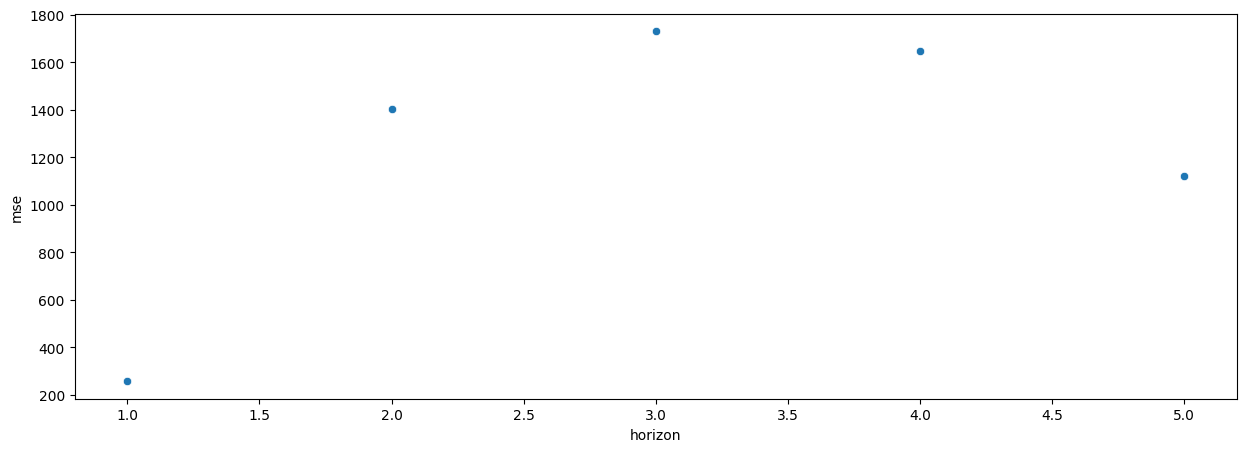

In [40]:
tmp = pd.DataFrame(horizon_mse).melt(var_name="horizon", value_name="mse").groupby("horizon").agg("mean")
sns.scatterplot(data=tmp, x="horizon", y="mse")
plt.show()

Unsurprisingly, the best `h` value is 1 or a one-step ahead forecast. Interestingly, we also find that a 4-step or 5-step **ahead** forecast is also viable. More viable in fact that a 2-step and 3-step ahead forecast. At least we know from a Linear Regression that we have the option to forecast further into the future.

# Multi-step Forecast

In a lot of applications, predicting a single point and being dependent on the actual values isn't all that valuable. From experience, stakeholders would often want to forecast 7 days in the future. You can see the obvious problem, right?

You can't really do that from what we've already learned because we're dependent on the actual values.

---

**Question:** What's the core difference between these two statements?

1. Our model can forecast each month accurately over a 5-year horizon, assuming we always feed it the actual values from the previous months.
the first one says that actual values are used in predicting
2. Our model can generate a 5-year monthly forecast in advance, without relying on any future actual values.
the second one says that predicted values are used, so errors accumulate. Dont assume to have a high accuracy because the errors compound
---

In cases where you can't retrain on the test set or when you can't have information on the test set at all provides a common conundrum for forecasters. Here we would rely on multi-step forecasting, which is defined as simply forecasting $n > 1$ steps into the future.

There are several ways to do a multi-step forecast. Some examples are
1. Recursive: continuously feed the prediction back to the model

2. Direct: create a model for each $n$ step ahead forecast. basically a one step ahead forecast with varying levels of h
very difficult because you have to tune each ARIMA model and also because very expensive
3. Single-shot: create a model (often a neural network) to forecast all $n$ steps simultaneously.

For us, it's more important to know recursive forecasting. 

## Recursive Forecasts

You can think of a recusrsive forecast as the same as our typical regression setup. However, instead of feeding it the actual values from the test set, we give it our forecasts instead. We're essentially recursively feeding-back our forecasts to our model in order to make another prediction.

You. just need to define the number of steps $n$

In [65]:
lr_recursive = LinearRegression()
rf_recursive = RandomForestRegressor(random_state=2212)

In [66]:
lr_recursive.fit(train_X, train_y)
rf_recursive.fit(train_X, train_y)
lookback = 10

lr_history = test_X[0].copy() # Get the last observations from the training set
rf_history = test_X[0].copy() # Get the last observations from the training set

T = len(test_y)

# Set where to save all forecasts
lr_forecasts = []
rf_forecasts = []

for t in range(T):
    # Get the input time series for each model
    lr_input_X = lr_history[-lookback:]
    rf_input_X = rf_history[-lookback:]

    # Predict based on the input time series
    lr_forecast = lr_recursive.predict([lr_input_X])
    rf_forecast = rf_recursive.predict([rf_input_X])

    # Save the forecasts
    lr_forecasts.append(lr_forecast)
    rf_forecasts.append(rf_forecast)

    # append forecast to historical
    # it's okay to append, because we're only getting the
    # last lookback period points
    lr_history = np.append(lr_history, lr_forecast)
    rf_history = np.append(rf_history, rf_forecast)    

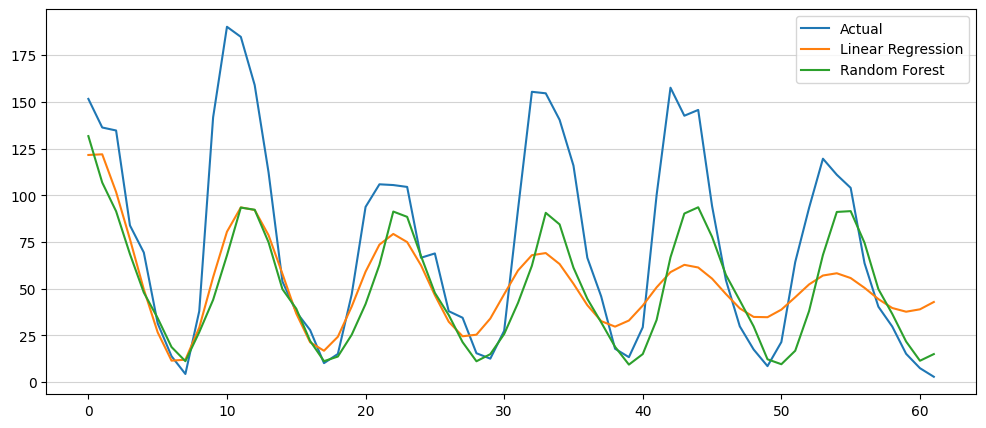

In [67]:
fig, ax = plt.subplots(figsize=(12, 5))

x_range = range(test_y.shape[0])

# convert forecasts into an array and flatten
lr_forecasts = np.asarray(lr_forecasts).flatten()
rf_forecasts = np.asarray(rf_forecasts).flatten()

test_y_flat = test_y.copy().flatten()

plt.plot(x_range, test_y_flat)
plt.plot(x_range, lr_forecasts)
plt.plot(x_range, rf_forecasts)

plt.legend(["Actual", "Linear Regression", "Random Forest"])
plt.grid(axis="y", c="lightgray")
plt.show()

random forest is very stable

---

**Question**: What do you notice?

---

# Supplemental: Topological visualization of time series pre-processing

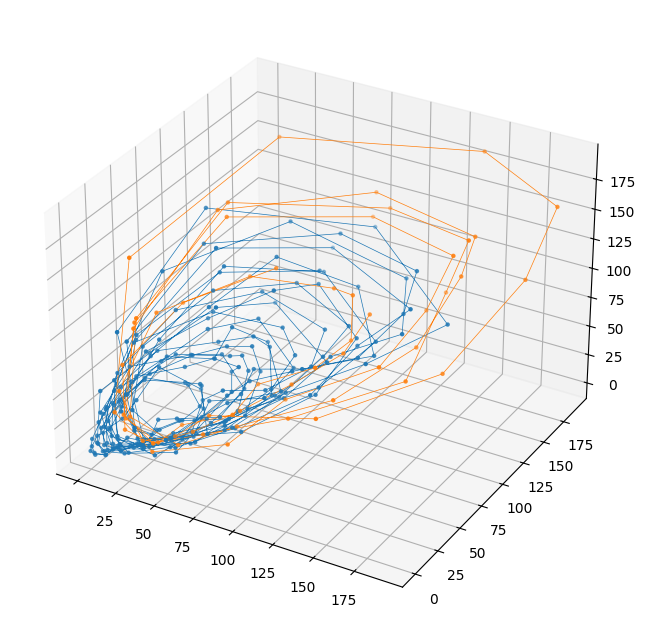

In [68]:
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection="3d")
ax.plot(train_X[:, 0], train_X[:, 1], train_X[:, 2], linewidth=0.5)
ax.scatter(train_X[:, 0], train_X[:, 1], train_X[:, 2], s=5)

ax.plot(test_X[:, 0], test_X[:, 1], test_X[:, 2], linewidth=0.5)
ax.scatter(test_X[:, 0], test_X[:, 1], test_X[:, 2], s=5)

plt.show()

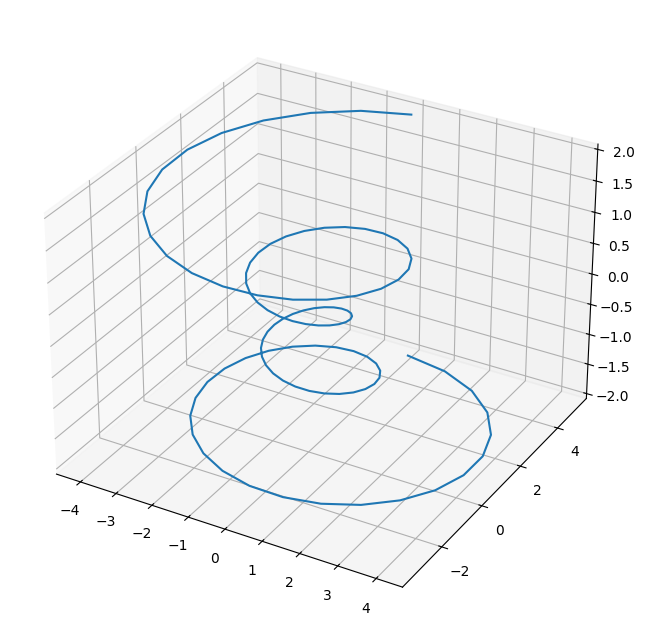

In [69]:
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection="3d")

theta = np.linspace(-4*np.pi, 4*np.pi, 100)
z = np.linspace(-2, 2, 100)
r = z**2 + 1
x = r * np.sin(theta)
y = r * np.cos(theta)

ax.plot(x, y, z)
plt.show()
